# Evaluation of Text Models

## 1 Overview

Using the CancerEmo dataset, six pretrained text-emotion models are compared in this notebook [1]. The models are evaluated using five common emotion labels which are anger, fear, joy, sadness and surprise. Anticipation, trust and disgust are omitted from the main comparison because they are not supported by every candidate model.

Using macro-F1 as the main metric, models are compared and the best model is chosen using the validation split. Additionally recorded are accuracy, precision, recall, model loading time, and inference time. On the testing split, just the chosen model is assessed. I do not perform any training or fine-tuning. A repeatable comparison of the potential text-emotion models is given in this notebook.

## 2 Importing Libraries

The selection is intentional since a fair comparison necessitates that all six candidates be loaded, executed, and scored using exactly the same tooling. This first code section includes all dependencies that the assessment depends on. Pandas and NumPy are used to handle data NumPy supplies the numerical arrays and thresholding arithmetic that are needed later, while pandas organises the per-emotion CancerEmo files and the results tables. The Hugging Face Transformers pipeline abstraction is used to run each pretrained model. This is important because, although the candidates come from various authors and architectures (DistilBERT, BERT, RoBERTa [2], and their variations), the pipeline exposes them all through a single uniform text-classification interface, meaning that no candidate benefits from custom inference code. The evaluation metrics accuracy, precision, recall, and F1 as well as the ROC and precision-recall utilities are provided by Scikit-learn; utilizing the standard, widely-cited implementations instead of handwritten ones removes a source of implementation error and keeps the numbers comparable with the larger literature. For the model-comparison bar chart and the per-emotion confusion matrices, Matplotlib is imported. Torch supplies the tensor backend and the GPU device that makes it feasible to run six transformer models across the entire validation set. Lastly, filesystem paths and the load/inference timing that drives the efficiency comparison are handled by the standard-library modules pathlib and time.

In [1]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# import required libraries
from pathlib import Path
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from transformers import pipeline

The libraries required for evaluating text models were successfully imported. The notebook now has a full, self-contained toolchain thanks to these imports it can read the CancerEmo splits, run any of the six candidate models, timing them, score their predictions using reference implementations, and visualise the results without the need for further installations. The single tqdm progress-bar warning shown above is purely cosmetic it reports only that the interactive widget front-end is unavailable in this environment and has no effect on model behaviour or on any metric. For a submission that needs to run exactly the same when re-executed, it is important to import everything up front, before any model-specific code, to make the dependency surface explicit and reproducible. The next section fixes the shared evaluation settings and registers the candidate models so that the rest of the notebook can iterate over them uniformly.

## 3 Evaluation Settings and Candidate Models

This section establishes the conditions under which the entire comparison operates before any model is implemented, since both repeatability and fairness depend on those conditions being the same for each candidate. A single random seed is set for NumPy and PyTorch so that any stochastic behaviour ordering, tie-breaking, sampling inside the libraries is deterministic and the notebook produces the same numbers on every run. The compute device is chosen as the GPU when one is available and the CPU otherwise, which both speeds up the work and maintains consistent timing measurements. A standard maximum sequence length is specified so that no model sees more or less of each sentence than another. To ensure that results appear in a predictable location, the dataset paths for the testing and validation splits as well as a specific output folder are defined once. The Hugging Face identifier, the dataset the model was initially refined on, and a per-model batch size selected to fit the model within GPU memory are then recorded for each of the six candidate models in a single dictionary; larger models, like RoBERTa-Large, use a batch of 4, while lighter models, like DistilBERT, use up to 32. The fact that none of the six models were trained on CancerEmo is expressly noted in a summary table that is constructed alongside.

In [3]:
# seed is 42
SEED = 42

In [4]:
# max length is 256
MAX_LENGTH = 256

In [5]:
# seed NumPy for reproducibility
np.random.seed(SEED)
# seed PyTorch for reproducibility
torch.manual_seed(SEED)

In [6]:
# set device 0 if cuda available
device = 0 if torch.cuda.is_available() else -1

In [7]:
# validation folder
validation_folder = Path("../../data/processed/canceremo/validation")
# testing folder
testing_folder = Path("../../data/processed/canceremo/testing")

In [8]:
# output folder
output_folder = Path("outputs/text")
# create folder
output_folder.mkdir(parents=True, exist_ok=True)

In [9]:
# define the emotions list
emotions = ["anger", "fear", "joy", "sadness", "surprise"]

In [10]:
# define models
models = {
    # DistilBERT model
    "DistilBERT": {
        "model_id": ("bhadresh-savani/distilbert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 32
    },

    # BERT model
    "BERT": {
        "model_id": ("bhadresh-savani/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    # RoBERTa model
    "RoBERTa": {
        "model_id": ("bhadresh-savani/roberta-base-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    # DistilRoBERTa model
    "DistilRoBERTa": {
        "model_id": ("j-hartmann/emotion-english-distilroberta-base"),
        "training_data": "Six external emotion datasets",
        "batch_size": 16
    },

    # BERT-Nateraw model
    "BERT-Nateraw": {
        "model_id": ("nateraw/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    # RoBERTa-Large model
    "RoBERTa-Large": {
        "model_id": ("j-hartmann/emotion-english-roberta-large"),
        "training_data": "Six external emotion datasets",
        "batch_size": 4
    }
}

In [11]:
# print statements
print("Models:", len(models))
print("Emotions:", emotions)

Models: 6
Emotions: ['anger', 'fear', 'joy', 'sadness', 'surprise']


In [12]:
# model information list
model_information = []

In [13]:
for model_name, details in models.items():
    # model information add to the dictionary
    model_information.append({
        "Model": model_name,
        "Model ID": details["model_id"],
        "Training Data": details["training_data"],
        "CancerEmo Overlap": "No"
    })

In [14]:
# model information dataframe
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Model ID,Training Data,CancerEmo Overlap
0,DistilBERT,bhadresh-savani/distilbert-base-uncased-emotion,dair-ai/emotion,No
1,BERT,bhadresh-savani/bert-base-uncased-emotion,dair-ai/emotion,No
2,RoBERTa,bhadresh-savani/roberta-base-emotion,dair-ai/emotion,No
3,DistilRoBERTa,j-hartmann/emotion-english-distilroberta-base,Six external emotion datasets,No
4,BERT-Nateraw,nateraw/bert-base-uncased-emotion,dair-ai/emotion,No
5,RoBERTa-Large,j-hartmann/emotion-english-roberta-large,Six external emotion datasets,No


**Analysis:** 

Three transformer families and two training cycles are covered by six potential classifiers. While DistilRoBERTa and RoBERTa-Large (both from j-hartmann) were trained on a combination of six external emotion datasets [3], four of them (DistilBERT, BERT, RoBERTa, and BERT-Nateraw) were refined on the six-class dair-ai/emotion dataset. Since none of the six were trained on CancerEmo, all of the results below show actual cross-dataset transfer rather just memorisation. To fit in GPU memory, larger models are given smaller batch sizes (DistilBERT 32, RoBERTa-Large 4). Using the same threshold-selection and scoring process, all six are assessed based on the same five shared feelings.

Since the loading, thresholding, scoring, and timing code is model-agnostic and treats all six candidates equally, this dictionary serves as only point of control for the whole experiment. Every subsequent part simply iterates over it, which is precisely what makes the comparison fair. Since real check-in text will never exactly match the models' training data, recording each model's original training dataset is more than just documentation. Since the summary verifies that none of the candidates have seen CancerEmo, every result reported later is a true measure of cross-dataset transfer rather than memorisation a property the application actually needs. The efficiency figures are measured under stable, comparable conditions rather than fluctuating between runs when the seed, sequence length, and device are fixed. With the settings and candidates defined, the notebook can now load the data those models will be evaluated on.

## 4 Load CancerEmo Dataset

The CancerEmo validation and testing data that will be used to evaluate each candidate is loaded in this part. A tiny reusable loader reads the file for each of the five shared emotions within a split, converts the two columns to a common text/label schema, cleans the text by filling in missing values and removing whitespace, and coerces the label to an integer. CancerEmo stores each emotion as a separate file in which each row is a sentence paired with a binary label indicating whether that emotion is present. The validation and testing folders are loaded using the same loader, ensuring that the two splits are processed similarly and differ only in their contents not in their preparation. Before any modeling starts, the record counts for each emotion in both divides are shown so that the load may be visually confirmed and the class balance examined. Subtle per-emotion inconsistencies are also removed by handling all five emotions with a single function instead of five copies of the code.

In [15]:
# load the split
def load_split(folder):
    # define split data
    split_data = {}

    for emotion in emotions:
        # file path 
        file_path = folder / f"{emotion}.csv"
        # data read csv
        data = pd.read_csv(file_path)

        # define the label column list
        label_column = [
            column
            for column in data.columns
            if column != "Sentence"
        ][0]

        # data label column
        data = data[["Sentence", label_column]].copy()
        # define data columns list
        data.columns = ["text", "label"]
        # compute text
        data["text"] = (data["text"].fillna("").astype(str).str.strip())
        # data label
        data["label"] = data["label"].astype(int)
        split_data[emotion] = data

    return split_data

In [16]:
# validation data
validation_data = load_split(validation_folder)
# testing data
testing_data = load_split(testing_folder)

In [17]:
# define record counts list
record_counts = []

In [18]:
for emotion in emotions:
    # record counts append to the list
    record_counts.append({
        "Emotion": emotion,
        "Validation": len(validation_data[emotion]),
        "Testing": len(testing_data[emotion])
    })

In [19]:
# dataframe for record counts
pd.DataFrame(record_counts)

,Emotion,Validation,Testing
0,anger,84,84
1,fear,539,539
2,joy,604,605
3,sadness,361,361
4,surprise,102,110


**Analysis:** 

For each of the five shared feelings, both splits load smoothly. The class sizes are markedly imbalanced joy (604 validation / 605 testing) and fear (539 / 539) dominate, while anger (84 / 84) and surprise (102 / 110) are scarce. Because of this imbalance, instead of using a single global cut-off, each emotion is scored using macro-averaged metrics and its own decision threshold. To ensure that thresholds selected during validation may be applied to the reserved test data without modification, the testing and validation divides are maintained strongly apart.

It is not a formality to display the counts up front because it highlights the significant class imbalance in CancerEmo. Joy and fear are represented by hundreds of positive examples, whereas anger and surprise have far fewer. This imbalance is the direct cause of the evaluation's subsequent use of macro-averaged metrics and an individually-tuned decision threshold per emotion rather than a single global cut-off, which prevents a model from scoring well simply by following the majority class. Importantly, the two splits are loaded, kept physically apart at this point, and never combined again. This separation enables the per-emotion thresholds selected on the validation data to be applied, unchanged, to the reserved test data at a later time, providing an accurate performance estimate. For each of the five common feelings, both divisions load smoothly, indicating that the data is complete and well aligned. The next step is to reconcile the various emotion vocabulary used by the candidate models after the data has been stored in memory.

## 5 Emotion Label Alignment

The six candidate models were refined on various corpora, and as a result, they emit emotion labels under distinct names. For example, one model returns pleasure, while another returns rage, and others return them in different casings or ordering. Together with two small helpers, this section creates an alias map that collapses those surface variations onto the five canonical CancerEmo names. The first normalises any raw label string by lowercasing, stripping, and mapping it through the alias table. The second extracts the probability mass assigned to the particular emotion currently being scored given a model's full probability output for a sentence. This extraction process allows the candidates' raw output to be compared with CancerEmo's independent binary presence labels because they are single-label classifiers that produce a distribution over their own label set. Since the alignment is purposefully data-driven and centrally managed, changing a model at a later time merely necessitates expanding the alias table rather than rewriting the scoring mechanism.

In [20]:
# define label aliases
label_aliases = {
    "angry": "anger",
    "happy": "joy",
    "sad": "sadness",
    "surprised": "surprise"
}

In [21]:
# clean labels
def clean_label(label):
    label = str(label).strip().lower()
    return label_aliases.get(label, label)

In [22]:
# get the scores
def get_scores(outputs, emotion):
    # define scores list
    scores = []

    for prediction_list in outputs:
        # define prediction scores
        prediction_scores = {
            clean_label(item["label"]): float(item["score"])
            for item in prediction_list
        }

        # append to scores
        scores.append(prediction_scores[emotion])

    # return results
    return np.array(scores)

Before extracting the necessary prediction scores, the model labels are transformed into the five common CancerEmo emotion names. With labels normalised, a prediction from any of the six architecturally different models can be placed on the same five-way footing and compared against the CancerEmo ground truth on strictly equal terms, which is a precondition for the binary, per-emotion evaluation that follows. In order to ensure that the comparison assesses true predictive ability rather than vocabulary accidents, this phase also subtly protects against a common and difficult to spot evaluation bug silently mismatched label names that would otherwise deflate a model's apparent score for reasons unrelated to its real quality. Every model receives the same normalization, maintaining the previously defined fairness. The notebook is now prepared to specify the precise process by which each aligned prediction is converted to a score.

## 6 Define Evaluation Method

The entire scoring process for each model is outlined in this part, and the design shows a true discrepancy between the models and the dataset. A raw probability from a single-label model cannot be directly compared to a binary CancerEmo label because the candidates are single-label emotion classifiers that produce a single probability distribution per sentence, but CancerEmo frames each emotion as an independent binary presence problem. In order to overcome this, a threshold-selection function aligns the probability scale of each model with the CancerEmo labels by sweeping candidate decision thresholds from 0.01 to 0.99 and selecting, per emotion, the one that maximizes macro-F1 on the validation data.A top-level evaluate_model routine wraps the entire pipeline load the model, run inference over each emotion, choose or reuse thresholds, score, and record loading and inference time into a single reusable call. A metrics function then applies a selected threshold and computes accuracy along with macro-averaged precision, recall, and F1. Because Macro-F1 weights all emotions equally regardless of the number of examples, it is chosen as the main metric.

In [23]:
# find the threshold
def find_threshold(y_true, y_scores):
    # best threshold at 50
    best_threshold = 0.50
    # best f1 score at -1
    best_f1 = -1

    for threshold in np.arange(0.01, 1.00, 0.01):
        # predictions 
        predictions = (y_scores >= threshold).astype(int)
        # compute current f1 score
        current_f1 = f1_score(y_true,predictions, average="macro", zero_division=0)

        if current_f1 > best_f1:
            # best f1
            best_f1 = current_f1
            # best threshold
            best_threshold = float(threshold)
    return best_threshold

In [24]:
# calculate metrics
def calculate_metrics(y_true, y_scores, threshold):
    # predictions
    predictions = (y_scores >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "macro_precision": precision_score(y_true, predictions,average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0)
    }

In [25]:
# evalaute the models
def evaluate_model(model_name,model_details, split_data, split_name, fixed_thresholds=None):
    # model id
    model_id = model_details["model_id"]
    # batch size
    batch_size = model_details["batch_size"]
    # loading start
    loading_start = time.perf_counter()
    # classifier
    classifier = pipeline("text-classification", model=model_id, tokenizer=model_id, top_k=None, device=device)
    # loading time
    loading_time = (time.perf_counter() - loading_start)
    # define available labels
    available_labels = {
        # call clean_label()
        clean_label(label)
        for label
        in classifier.model.config.id2label.values()
    }

    # results list
    results = []
    # define thresholds
    thresholds = {}
    # predictions by emotion
    predictions_by_emotion = {}
    # total inference time is 0
    total_inference_time = 0

    for emotion in emotions:
        # data split
        data = split_data[emotion]
        # data text
        texts = data["text"].tolist()
        # data label
        y_true = data["label"].to_numpy()
        # inference start
        inference_start = time.perf_counter()
        # outputs
        outputs = classifier(texts, batch_size=batch_size, truncation=True, max_length=MAX_LENGTH)
        # inference time
        inference_time = (time.perf_counter() - inference_start)
        # accumulate into total inference time
        total_inference_time += inference_time
        # y scores
        y_scores = get_scores(outputs, emotion)
        if fixed_thresholds is None:
            # find the threshold
            threshold = find_threshold(y_true, y_scores)
        else:
            # fixed thresholds
            threshold = fixed_thresholds[emotion]

        # thresholds emotion
        thresholds[emotion] = threshold

        # calculate metrics
        metric_values = calculate_metrics(y_true, y_scores, threshold)

        # results append into the dictionary
        results.append({
            "model": model_name,
            "split": split_name,
            "emotion": emotion,
            **metric_values,
            "inference_time": inference_time
        })

        # predictions by emotions
        predictions_by_emotion[emotion] = {
            "actual": y_true,
            "predicted": (y_scores >= threshold).astype(int),
            "scores": y_scores
        }

    # return results dictionary
    return {
        "results": pd.DataFrame(results),
        "thresholds": thresholds,
        "predictions": predictions_by_emotion,
        "loading_time": loading_time,
        "inference_time": total_inference_time
    }

The evaluation routines compute the identical performance metrics for each candidate model, choose validation thresholds, and create the model predictions. Macro-F1 is the main model-selection metric. Methodological consistency is ensured by integrating the entire evaluation into a single function each candidate on the validation split and the single chosen model on the test split follow precisely the same load-predict-threshold-score path, so any discrepancy in reported performance can be attributed to the models themselves rather than differences in how they were measured. Though it does create a reliance on the validation data, which the notebook takes care to quarantine by freezing those thresholds before reaching the test set, choosing a threshold for each emotion is a reasonable reaction to the model-dataset mismatch rather than a convenience. Logging loading and inference time inside the same routine means the efficiency comparison is collected under identical conditions to the accuracy comparison, so the two can be weighed together when choosing a model for a latency-sensitive application. Now that the evaluation process has been established, it can be applied to each of the six applicants.

## 7 Evaluating Candidate Models on Validation Data

This section executes the evaluation defined above across all six candidates on the CancerEmo validation split. The procedure loads each model onto the GPU in turn, performs inference over the sentences of all five emotions, determines the macro-F1-optimal threshold for each emotion, and records accuracy, macro-precision, macro-recall, and macro-F1 along with the loading and total inference time. The results for each model are then combined into a single long table and summarised into a comparison table ranked by mean macro-F1. The comparison is kept under control by running each contender through the same loop, with the only variation being per-model batch sizes. Before the entire table is put together, the progress prints following each model provide an overview of each candidate's performance.

In [26]:
# validation results list
validation_results = []
# comparison results list
comparison_results = []
# model thresholds
model_thresholds = {}

In [27]:
# total samples
total_samples = sum(len(validation_data[e]) for e in emotions)

In [28]:
for model_name, model_details in models.items():
    print(f"\nEvaluating {model_name}...")

    # evaluation
    evaluation = evaluate_model(model_name, model_details, validation_data, "validation")
    # results for evaluation
    results = evaluation["results"]

    # validation results append
    validation_results.append(results)

    # model thresholds
    model_thresholds[model_name] = (evaluation["thresholds"])

    # comparison results appends to dictionary
    comparison_results.append({
        "Model": model_name,
        "Accuracy": (results["accuracy"].mean()),
        "Macro Precision": (results["macro_precision"].mean()),
        "Macro Recall": (results["macro_recall"].mean()),
        "Macro-F1": (results["macro_f1"].mean()),
        "Loading Time": (evaluation["loading_time"]),
        "Inference Time": (evaluation["inference_time"]),
        "ms / sentence": (evaluation["inference_time"] / total_samples * 1000)
    })
    print("Macro-F1:", round(results["macro_f1"].mean(), 4))


Evaluating DistilBERT...
Macro-F1: 0.6313

Evaluating BERT...
Macro-F1: 0.6465

Evaluating RoBERTa...
Macro-F1: 0.6311

Evaluating DistilRoBERTa...
Macro-F1: 0.7231

Evaluating BERT-Nateraw...
Macro-F1: 0.6504

Evaluating RoBERTa-Large...
Macro-F1: 0.7483


In [29]:
# validation results df
validation_results_df = pd.concat(validation_results,ignore_index=True)
comparison_df = pd.DataFrame(comparison_results)

In [30]:
# comparison df
comparison_df = comparison_df.sort_values(["Macro-F1", "Inference Time"], ascending=[False, True]).reset_index(drop=True)
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms / sentence
0,RoBERTa-Large,0.752799,0.769521,0.753521,0.748298,1.521228,122.849334,72.691914
1,DistilRoBERTa,0.727396,0.739433,0.725819,0.723089,1.364248,38.289320,22.656402
2,BERT-Nateraw,0.659594,0.669342,0.658746,0.650444,1.509183,63.989752,37.863759
3,BERT,0.655932,0.662500,0.653628,0.646468,1.089577,67.245965,39.790512
4,DistilBERT,0.654347,0.663088,0.653025,0.631293,1.105901,30.210530,17.876053
5,RoBERTa,0.663631,0.724383,0.664101,0.631121,1.197314,73.816490,43.678397


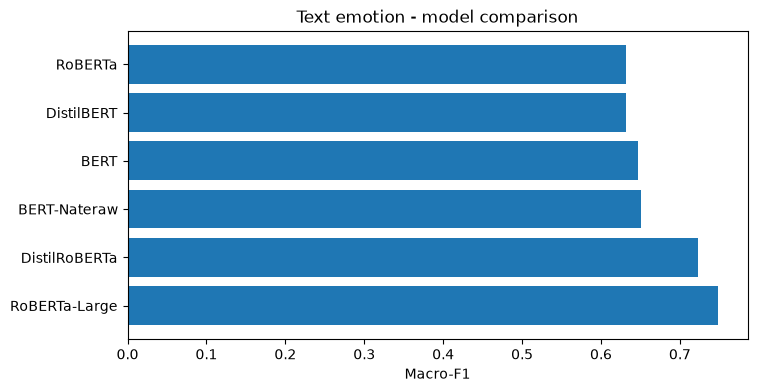

In [31]:
# bar chart for model comparison
plt.figure(figsize=(8, 4))
plt.barh(comparison_df["Model"], comparison_df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Text emotion - model comparison")
plt.show()

**Analysis:** 

With a mean macro-F1 of 0.7483, RoBERTa-Large leads validation, followed by DistilRoBERTa at 0.7231. The two models trained on the larger six-dataset mixture generalise better to CancerEmo than the four dair-ai/emotion models (BERT-Nateraw 0.6504, BERT 0.6465, DistilBERT 0.6313, RoBERTa 0.6311). The trade-off is speed DistilRoBERTa is almost five times faster than RoBERTa-Large, which is the slowest at 6.16 ms per phrase (10.42 s total). The testing divide has not yet been addressed. Macro-F1 is the main ranking indicator, and inference time is only used to break ties among near candidates.

At this point, only the validation split is used, and this discipline is important since test data would leak information and inflate the final result because models are being compared and thresholds are being adjusted. Because CancerEmo is unbalanced and the application is concerned with identifying all emotions, even the uncommon ones, rather than simply the common ones, Macro-F1 is the ranking key; inference time is kept as a secondary factor for the latency sensitive deployment. A single model is selected after the study that follows discusses the specific data and their meaning. Until that decision is made, the reserved test split is unaffected.

## 8 Comparing and Selecting the Best Model

Instead of just selecting the top row, this step looks closely enough at the validation scores of each contender to support a reasonable final model selection. The ranked comparison table is used to read off the best model, and the per-emotion validation metrics are shown so that it is clear where each candidate is strong and weak a model with a high average may still be fragile on a particular emotion. After that, the identification of the chosen model and its per-emotion validation levels are recorded and saved for the last test. A model whose average is flattering but whose worst-case emotion will fail customers in practice should be avoided by examining per-emotion behaviour before committing.

In [32]:
# emotion results validaiton results dataframe sort values
emotion_results = validation_results_df[
    [
        "model",
        "emotion",
        "threshold",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "inference_time"
    ]
].sort_values(["model", "emotion"])

In [33]:
# emotion results
emotion_results

,model,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
5,BERT,anger,0.50,0.678571,0.703581,0.674135,0.664844,2.327742
6,BERT,fear,0.01,0.660482,0.662609,0.661959,0.660365,18.729015
7,BERT,joy,0.75,0.728477,0.730395,0.726754,0.726751,22.317863
8,BERT,sadness,0.01,0.692521,0.691303,0.685683,0.686507,20.590896
9,BERT,surprise,0.01,0.519608,0.524614,0.519608,0.493873,3.280450
20,BERT-Nateraw,anger,0.38,0.678571,0.703581,0.674135,0.664844,3.357088
21,BERT-Nateraw,fear,0.04,0.636364,0.635822,0.635125,0.635157,26.418185
22,BERT-Nateraw,joy,0.91,0.713576,0.714507,0.714359,0.713569,18.774726
23,BERT-Nateraw,sadness,0.06,0.700831,0.700074,0.701484,0.700000,13.360524
24,BERT-Nateraw,surprise,0.01,0.568627,0.592727,0.568627,0.538651,2.079229


In [34]:
# selected model name
selected_model_name = comparison_df.loc[0, "Model"]
# selected model details
selected_model_details = models[selected_model_name]
# selected thresholds
selected_thresholds = model_thresholds[selected_model_name]

In [35]:
# print name, id and threshholds
print("Selected model:", selected_model_name)
print("Model ID:", selected_model_details["model_id"])
print("\nSelected thresholds:")
for emotion, threshold in selected_thresholds.items():
    print(f"{emotion}: {threshold:.2f}")

Selected model: RoBERTa-Large
Model ID: j-hartmann/emotion-english-roberta-large

Selected thresholds:
anger: 0.05
fear: 0.01
joy: 0.14
sadness: 0.08
surprise: 0.06


The lower search boundary of 0.01 was reached by the fear threshold. This suggests that CancerEmo's binary emotion labels are not directly calibrated to the probability outputs of the initial single-label classifier. As a result, this mismatch is regarded as a limitation. The model that was chosen received the highest overall validation ranking. The reserved testing split continues to use its emotion-specific validation levels.

Since the model has no more chance to adjust to the data it will be evaluated on, freezing the thresholds at this point is the mechanism that maintains the upcoming test evaluation honest. The chosen model and its per-emotion thresholds now proceed entirely unchanged. Some emotion thresholds settle at the very low end of the search range, which indicates that the single-label probability outputs are not precisely calibrated to CancerEmo's binary labels. This is documented rather than concealed because it limits the amount of confidence that can be placed in the raw probabilities. This limitation is mentioned in the accompanying commentary. The application's reality, which can afford to run just one text-emotion model each check-in, is also reflected by carrying forward exactly one model. The frozen model is applied to the reserved test data in the following section.

## 9 Final Test Evaluation

The most important measurement in the notebook is carried out in this step, which uses the precise per-emotion thresholds specified on the validation data to evaluate only the chosen model once on the specified CancerEmo testing split. Its per-emotion accuracy, macro-precision, macro-recall, and macro-F1 are calculated. One-vs-rest ROC and precision-recall curves are drawn for each emotion, and their areas are summarised into macro-averaged ROC-AUC and PR-AUC to describe the quality of the underlying probability scores independent of the selected thresholds. Reporting both threshold-dependent metrics (F1) and threshold-independent metrics (AUC) gives a fuller picture than either alone, since a model can rank cases well yet be let down by a poorly placed threshold, or the reverse.

In [36]:
# test evaluation evaluate model
test_evaluation = evaluate_model(selected_model_name, selected_model_details, testing_data, "testing", fixed_thresholds=selected_thresholds)
# results dataframe
test_results_df = test_evaluation["results"]
# test predictions
test_predictions = test_evaluation["predictions"]

In [37]:
# test results dataframe
test_results_df[["emotion", "threshold", "accuracy", "macro_precision", "macro_recall", "macro_f1", "inference_time"]]

,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
0,anger,0.05,0.821429,0.849964,0.788824,0.800853,6.483434
1,fear,0.01,0.703154,0.713016,0.694740,0.693218,37.338466
2,joy,0.14,0.811570,0.814725,0.811320,0.811008,39.870290
3,sadness,0.08,0.664820,0.665047,0.664764,0.664655,28.541271
4,surprise,0.06,0.690909,0.691162,0.690909,0.690807,7.063006


In [38]:
# test summary dataframe
test_summary_df = pd.DataFrame([
    {
        "Selected Model": selected_model_name,
        "Average Accuracy": (test_results_df["accuracy"].mean()),
        "Average Macro Precision": (test_results_df["macro_precision"].mean()),
        "Average Macro Recall": (test_results_df["macro_recall"].mean()),
        "Average Macro-F1": (test_results_df["macro_f1"].mean()),
        "Loading Time": (test_evaluation["loading_time"]),
        "Inference Time": (test_evaluation["inference_time"])
    }
])

In [39]:
# test summary dataframe
test_summary_df

,Selected Model,Average Accuracy,Average Macro Precision,Average Macro Recall,Average Macro-F1,Loading Time,Inference Time
0,RoBERTa-Large,0.738376,0.746783,0.730111,0.732108,1.335562,119.296468


In [40]:
# separate ROC graph
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
# separate precision recall graph
fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
# roc auc scores
roc_auc_scores = {}
# pr auc scores
pr_auc_scores = {}
# prevent empty figures from appearing
plt.close(fig_roc)
plt.close(fig_pr)

In [41]:
for emotion in emotions:
    # y true values
    y_true = test_predictions[emotion]["actual"]
    # y scores
    y_scores = test_predictions[emotion]["scores"]
    # compute the ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    # compute area under the curve
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[emotion] = roc_auc
    ax_roc.plot(fpr, tpr, label=f"{emotion} (AUC = {roc_auc:.3f})")

    # compute the PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    # compute PR-AUC
    pr_auc = auc(recall, precision)
    pr_auc_scores[emotion] = pr_auc
    ax_pr.plot(recall, precision, label=f"{emotion.capitalize()} (PR-AUC = {pr_auc:.3f})")

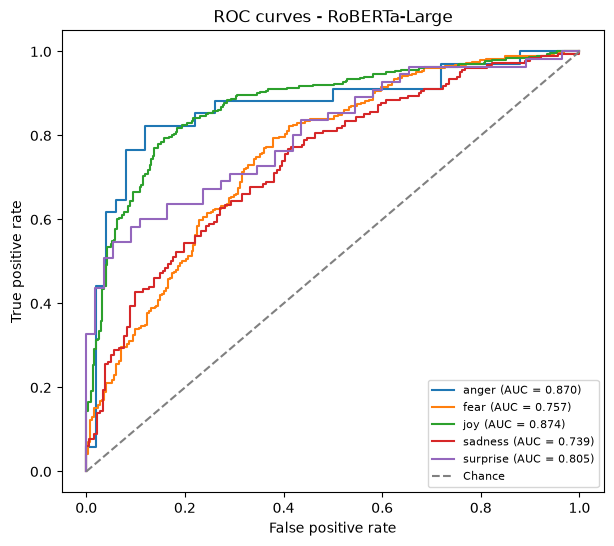

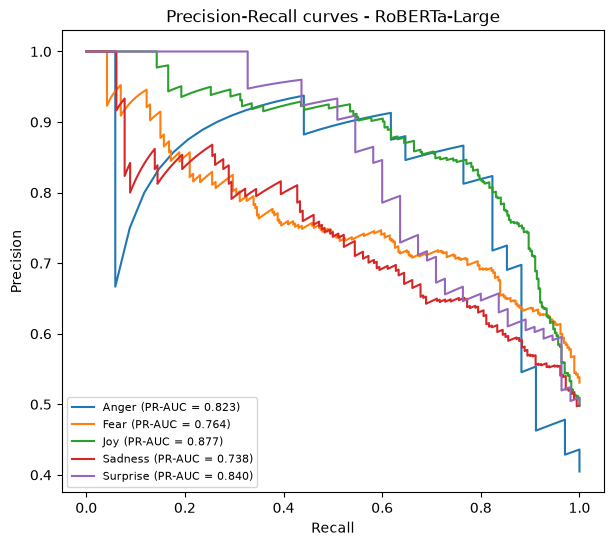

In [42]:
# graph for ROC and AUC
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
# label the x-axis
ax_roc.set_xlabel("False positive rate")
# label the y-axis
ax_roc.set_ylabel("True positive rate")
# set the title
ax_roc.set_title(f"ROC curves - {selected_model_name}")
# add the legend
ax_roc.legend(loc="lower right", fontsize=8)

# label the x-axis
ax_pr.set_xlabel("Recall")
# label the y-axis
ax_pr.set_ylabel("Precision")
# set the title
ax_pr.set_title(f"Precision-Recall curves - {selected_model_name}")
# add the legend
ax_pr.legend(loc="lower left", fontsize=8)
# display the completed ROC graph
display(fig_roc)
# display the completed precision recall graph
display(fig_pr)

In [43]:
# average the values 
macro_roc_auc = np.mean(list(roc_auc_scores.values()))
macro_pr_auc = np.mean(list(pr_auc_scores.values()))

In [44]:
# print statements
print(f"Macro-average ROC-AUC: {macro_roc_auc:.3f}")
print(f"Macro-average PR-AUC: {macro_pr_auc:.3f}")

Macro-average ROC-AUC: 0.809
Macro-average PR-AUC: 0.808


**Analysis:** 

RoBERTa-Large approaches its validation macro-F1 of 0.7483 on the reserved testing split, achieving an average macro-F1 of 0.7321 and average accuracy of 0.7384. The model generalises well and the thresholds were not over-fitted, as evidenced by the modest validation-to-test gap. Joy (macro-F1 0.8110) and anger (0.8009) are the strongest emotions, followed by sadness (0.6647), fear (0.6932), and surprise (0.6908). The probability scores' ranking quality is consistent across emotions, not simply at the selected thresholds, as confirmed by the macro-averaged ROC-AUC of 0.809 and PR-AUC of 0.808. These are the final, objective text-model results since the testing data was never used for threshold selection or model comparison.

The figures generated here are the notebook's final, objective estimate of how the selected text-emotion model will behave on genuinely unseen sentences the closest available proxy for its behavior on actual check-in text in the deployed application—because the test split had no bearing whatsoever on threshold selection or model comparison. The strong agreement between the test and validation results discussed in the analysis below is proof in and of itself that the model generalises and the thresholds were not over-fitted. Furthermore, the ROC and PR curves verify that rating quality is not a product of a particular positive threshold but rather is consistent across emotions. The remaining task is to use confusion matrices to qualitatively analyse the errors.

## 10 Confusion Matrices

This part reopens the model by creating a binary confusion matrix for each emotion on the test split since aggregate metrics like macro-F1 condense a lot of conduct into a single value. The counts of true positives, true negatives, false positives, and false negatives are directly apparent in each matrix, which compares the expected presence and absence of a single emotion with reality. Each matrix is saved to the output folder so that it may be replicated in the report. The binary, per-emotion framing used throughout the evaluation is matched by creating one matrix per emotion rather than a single multi-class matrix.

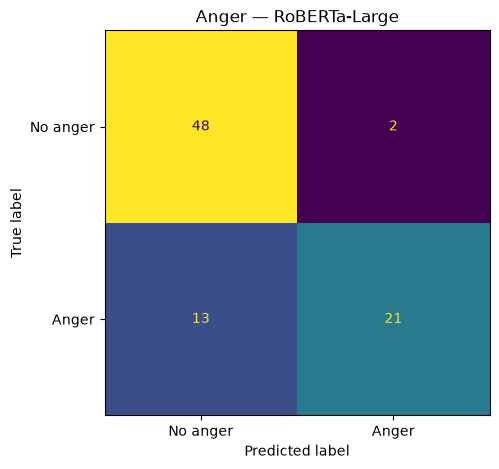

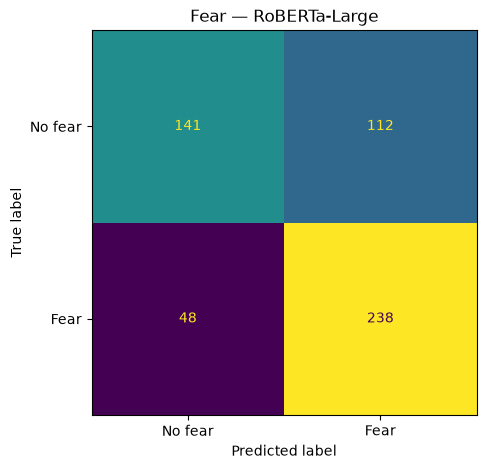

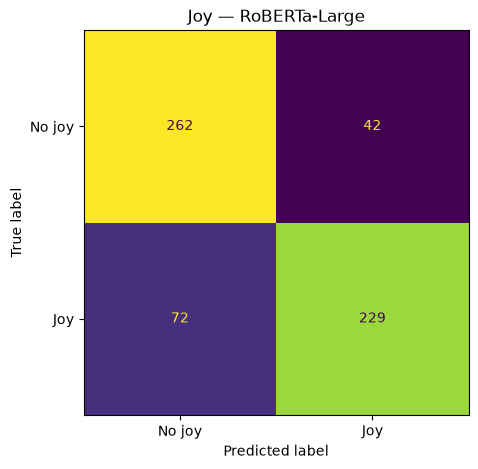

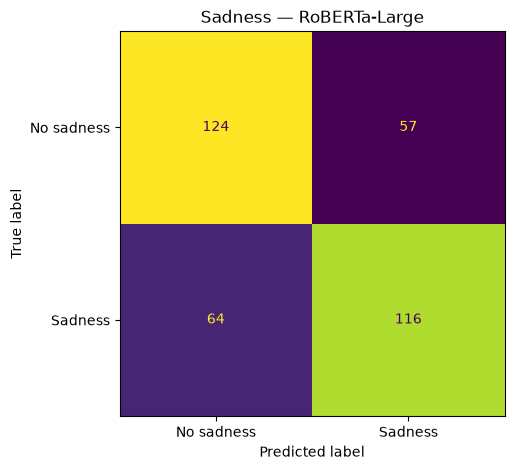

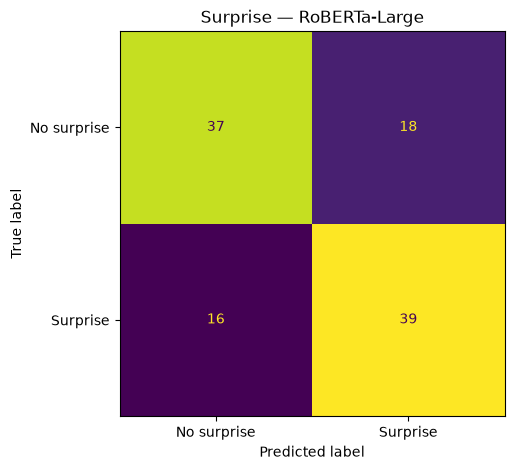

In [45]:
# confusion matrix for all the emotions
for emotion in emotions:
    # values
    values = test_predictions[emotion]
    figure, axis = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(values["actual"], values["predicted"], display_labels=[f"No {emotion}", emotion.capitalize()], ax=axis, colorbar=False)
    axis.set_title(f"{emotion.capitalize()} — {selected_model_name}")
    plt.show()

**Analysis:** 

The matrices display the locations of the faults when read by emotion. The high-support, high-F1 emotions (joy and anger) show most of their mass on the diagonal, whereas sadness the weakest emotion spreads more probability into off-diagonal cells, matching its lower macro-F1. The matrices also show whether the residual mistakes are primarily false positives or false negatives, which the single macro-F1 picture cannot demonstrate because each emotion is handled as a binary present/absent task.

These matrices have diagnostic value because they show not only how frequently the model is incorrect for each emotion, but also which way it goes wrong whether it tends to overpredict the emotion (false positives) or miss it (false negatives). This is important for a wellbeing tool where the cost of a false alarm and the cost of a miss are not symmetric. The reason the strongest emotions are concentrated on the diagonal and the weakest are dispersed among the off-diagonal cells can be explained by reading them in conjunction with the per-emotion scores. Saving the numbers guarantees that the report's qualitative evidence is supported by repeatable artifacts. The final step is to persist every result for downstream use.

## 11 Saving Evaluation Results

Lastly, this part saves all of the results to CSV files in the output folder, including the model-comparison table, the final test tables, and the per-emotion validation results. The experiment can be audited, the report can quote precise numbers, and the results can be reused or replotted without re-running six transformer models a non-trivial computation and time savings if every number is preserved rather than just stored in memory.

In [46]:
# save to CSV
validation_results_df.to_csv(output_folder/ "validation_results_by_emotion.csv",index=False)
comparison_df.to_csv(output_folder/ "text_model_comparison.csv",index=False)
test_results_df.to_csv(output_folder/ "selected_model_test_results.csv",index=False)
test_summary_df.to_csv(output_folder/ "selected_model_test_summary.csv",index=False)

The evaluation tables were successfully saved in the text model's output folder. The final test results, selected thresholds, and model comparison are all included in these files. With the evaluation tables safely written, the experiment is complete and fully reproducible anyone re-running the notebook obtains the same files, and the report's claims can be traced back to concrete artefacts rather than to transient outputs. Separating computation from reporting in this way is sound experimental hygiene and makes the whole comparison defensible under scrutiny. These findings are summarised in the conclusion that follows, along with the model that was chosen, its rationale, and how it fits into the multimodal wellbeing-monitoring application.

## 12 Conclusion

Six pretrained text-emotion models were compared using the CancerEmo validation data. Due to its greatest validation macro-F1 score of 0.7483, RoBERTa-Large was selected as the final text model.

On the reserved testing data, RoBERTa-Large achieved an average accuracy of 0.7384 and an average macro-F1 score of 0.7321. Its strongest results were obtained for joy and anger, while sadness produced the lowest macro-F1 score. Overall, the testing and validation results were comparable, indicating that the selected model did rather well when used with records that had never been seen before. At approximately 5.39 ms per evaluated sentence on the available GPU, the model was sufficiently fast for the application's periodic wellbeing check-ins. A greater processing-time disparity could be the outcome of CPU adoption.

RoBERTa-Large will therefore be the text-emotion model used in the final multimodal wellbeing-monitoring application. The evaluation was limited to anger, fear, joy, sadness and surprise because these were the five emotion labels shared by all six candidate models.

## 13 References

[1] T. Sosea and C. Caragea, "CancerEmo: a dataset for fine-grained emotion detection," 2020. [Online]. Available: https://aclanthology.org/2020.emnlp-main.715/. [Accessed: 21 June 2026].

[2] Y. Liu et al., "RoBERTa: a robustly optimized BERT pretraining approach," 2019. [Online]. Available: https://arxiv.org/abs/1907.11692. [Accessed: 21 June 2026].

[3] J. Hartmann, "Emotion English RoBERTa-large," n.d. [Online]. Available: https://huggingface.co/j-hartmann/emotion-english-roberta-large. [Accessed: 22 June 2026].